# 3. Curvature analysis
After obtaining the optimized neural field, we extract the membrane surface as the zero level set of the phase field using marching cube algorithm. We then calculate the mean and Gaussian curvatures.

##### Input:
- `output/stage2_{lambda}/checkpoint_10000` (phase field)

##### Output:
- `output/stage2_{lambda}/surface_10000.npz`
- `output/stage2_{lambda}/surface_10000.vtk` (visualizable through Paraview)

In [3]:
import sys
import os
import numpy as np
from pathlib import Path

#### Add program source to sys.path ####
project_root = Path().resolve()
sys.path.append(str(project_root / "../../src"))

#### Extract membrane surface and calculate curvatures

In [4]:
from pinn.normal_curves import write_vtk_polydata, calc_norm_curv_K_force
from flax.training import checkpoints

# ==== Parameters =====
output_dir = "../output"
shape = "bud-11"
lambda_1 = 100000  # data loss
lambda_2 = 100000  # B.C. loss
lambda_3 = 1       # physics loss
lambda_4 = 10      # smoothing loss
step = 10000
stage = 2
                    
# ==== Load checkpoint data =====
checkpoint_dir = f"{output_dir}/stage{stage}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ==== Calculate quantities =====
verts, faces, norms, theta, curvs, gauss, force = calc_norm_curv_K_force(checkpoint_data)

## ==== Save NPZ =====
npz_path = f"{checkpoint_dir}/surface_{step}.npz"
np.savez(npz_path, verts=verts, faces=faces, norms=norms, theta = theta, curvs=curvs, gauss=gauss, force=force)

## ==== Save VTK =====
vtk_path = f"{checkpoint_dir}/surface_{step}.vtk"
write_vtk_polydata(vtk_path, verts, faces,
                   point_vectors={"Normal": norms, "Force": force},
                   point_scalars={"MeanCurvature": curvs, "GaussianCurvature": gauss, "Angle": theta})

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/tutorial/output/stage2_100000_100000_1_10/checkpoint_10000


#### Visualize curvatures in 3D

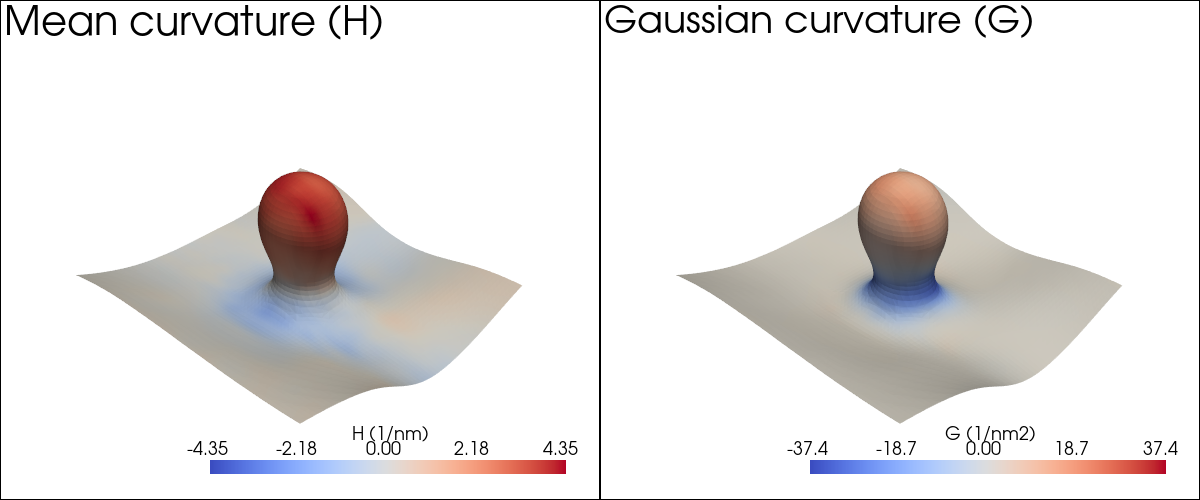

In [31]:
import pyvista as pv
pv.set_jupyter_backend("static")

# data = np.load(npz_path)
# verts = data["verts"]  # Vertices
# faces = data["faces"]  # Faces
# curvs = data["curvs"]  # Mean curvatures
# gauss = data["gauss"]  # Gaussian curvatures

verts_pv = verts[:, [0, 2, 1]]
faces_pv = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int64)
faces_pv = faces_pv.flatten()

mesh = pv.PolyData(verts_pv, faces_pv)

mesh_H = mesh.copy()
mesh_K = mesh.copy()

mesh_H["H"] = curvs
mesh_K["K"] = gauss

H_lim = np.max(np.abs(curvs))
K_lim = np.max(np.abs(gauss))

plotter = pv.Plotter(shape=(1, 2), window_size=(1200, 500))

plotter.subplot(0, 0)
plotter.add_text("Mean curvature (H)", font_size=20)
plotter.add_mesh(
    mesh_H,
    scalars="H",
    cmap="coolwarm",
    clim=[-H_lim, H_lim],
    scalar_bar_args={"title": "H (1/nm)"},
)

plotter.subplot(0, 1)
plotter.add_text("Gaussian curvature (G)", font_size=20)
plotter.add_mesh(
    mesh_K,
    scalars="K",
    cmap="coolwarm",
    clim=[-K_lim, K_lim],
    scalar_bar_args={"title": "G (1/nm2)"},
)

plotter.link_views()
plotter.show()
